# Lab Task 5: Black Hat

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

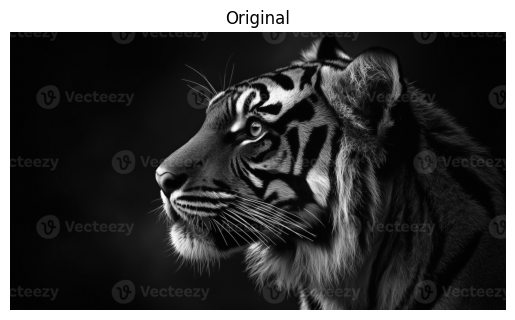

In [2]:
img = cv2.imread('../Open_CV_Practice/assets/lion.jpeg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.show()

## Black Hat Operation

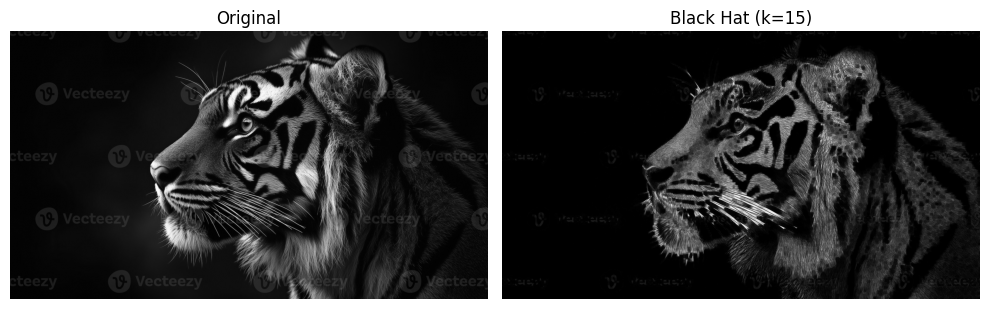

In [3]:
# Black Hat = Closing - Original
# Reveals small dark details/features that are darker than surroundings

kernel   = np.ones((15, 15), np.uint8)
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,      cmap='gray'); axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(blackhat, cmap='gray'); axes[1].set_title('Black Hat (k=15)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Kernel Size Comparison

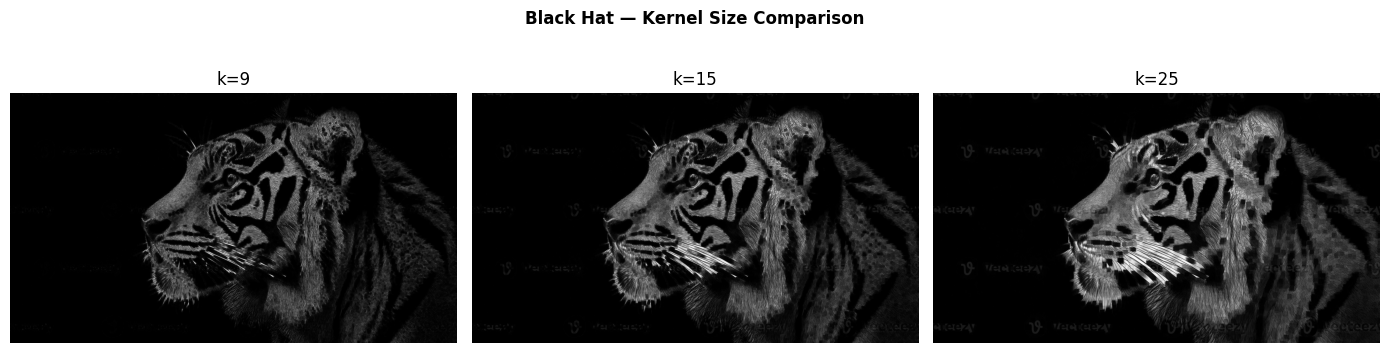

In [4]:
sizes = [9, 15, 25]
bhats = [cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, np.ones((k, k), np.uint8)) for k in sizes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Black Hat — Kernel Size Comparison', fontweight='bold')
for ax, res, k in zip(axes, bhats, sizes):
    ax.imshow(res, cmap='gray'); ax.set_title(f'k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()

## Top Hat vs Black Hat Comparison

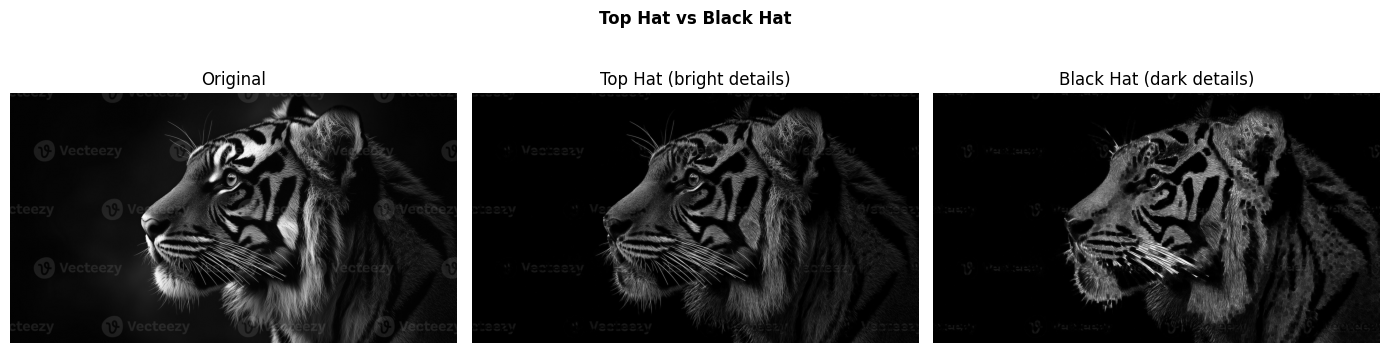

Black Hat = Closing - Original
Extracts small dark features/details smaller than the kernel size
Top Hat  → detects bright features on dark background (e.g. light spots)
Black Hat → detects dark features on bright background (e.g. dark text, cracks)
Common uses: reading dark text on bright paper, detecting cracks, shadow analysis


In [5]:
kernel  = np.ones((15, 15), np.uint8)
tophat  = cv2.morphologyEx(img, cv2.MORPH_TOPHAT,  kernel)

imgs   = [img, tophat, blackhat]
labels = ['Original', 'Top Hat (bright details)', 'Black Hat (dark details)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Top Hat vs Black Hat', fontweight='bold')
for ax, im, lbl in zip(axes, imgs, labels):
    ax.imshow(im, cmap='gray'); ax.set_title(lbl); ax.axis('off')
plt.tight_layout(); plt.show()

print('Black Hat = Closing - Original')
print('Extracts small dark features/details smaller than the kernel size')
print('Top Hat  → detects bright features on dark background (e.g. light spots)')
print('Black Hat → detects dark features on bright background (e.g. dark text, cracks)')
print('Common uses: reading dark text on bright paper, detecting cracks, shadow analysis')